In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_PATH = os.path.join("..", "vr_legibility_train.csv")

In [16]:
#load the data set
df = pd.read_csv(DATA_PATH)[["yaw", "pitch", "size", "label"]]
print(df.head()) 
print("\n")
print(df.info())
#no missing values, all data types are numeric

     yaw  pitch   size  label
0 -47.30  25.70  201.0      0
1   2.11  18.17  122.9      1
2  45.19  42.13   10.6      0
3 -33.54   0.72    6.5      0
4  18.72   4.42   17.3      1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1395 entries, 0 to 1394
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   yaw     1395 non-null   float64
 1   pitch   1395 non-null   float64
 2   size    1395 non-null   float64
 3   label   1395 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 43.7 KB
None


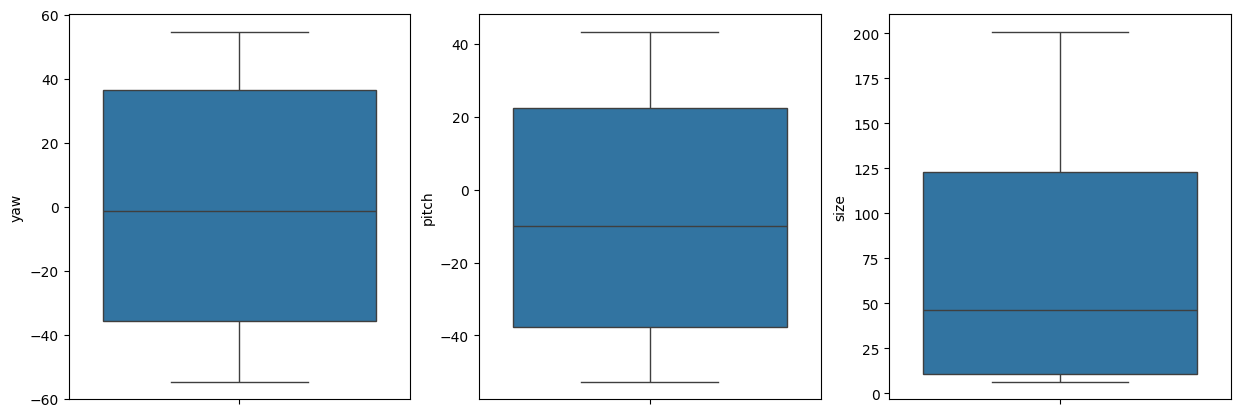

In [28]:
#Anomaly Detection

fig,axes = plt.subplots(1,3, figsize=(15,5))
sns.boxplot(data=df['yaw'], ax=axes[0])
sns.boxplot(data=df['pitch'], ax=axes[1])
sns.boxplot(data=df['size'], ax=axes[2])
plt.show()
#no outliers detected in the data set

C:\Users\psgve\AppData\Local\Temp\ipykernel_50688\2015316777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['label'], palette='Set2')


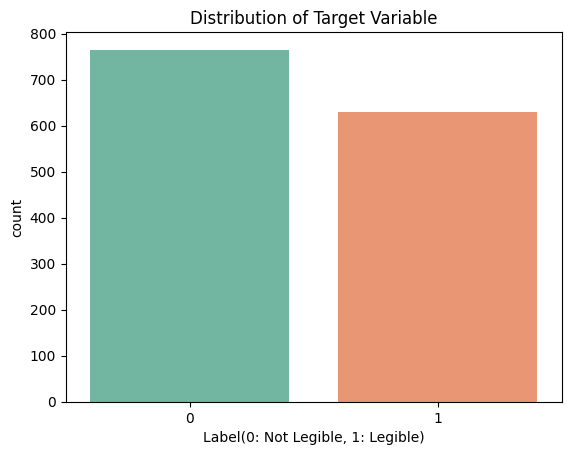

In [33]:
#target distribution

sns.countplot(x=df['label'], palette='Set2')
plt.title("Distribution of Target Variable")
plt.xlabel("Label(0: Not Legible, 1: Legible)")
plt.show()

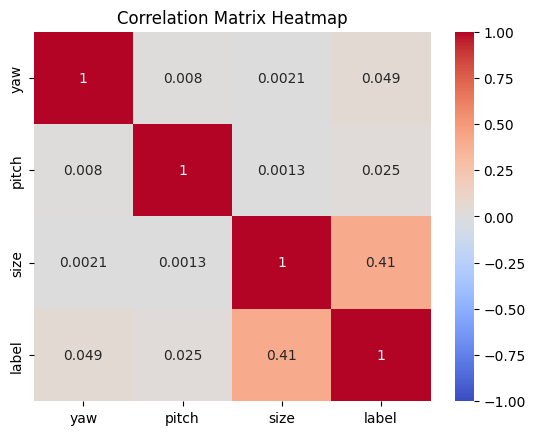

In [ ]:
#multicollinearity check

correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, vmin=-1, cmap='coolwarm')

plt.title('Correlation Matrix Heatmap')
plt.show()


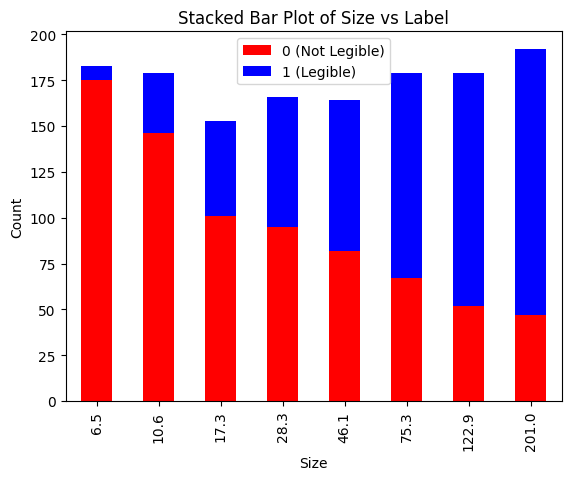

In [ ]:
#size vs label distribution
size_label_counts = df.groupby(['size', 'label']).size().unstack(fill_value=0)

size_label_counts.plot(kind='bar', stacked=True, color=['red', 'blue'])
plt.title('Stacked Bar Plot of Size vs Label')
plt.legend(['0 (Not Legible)', '1 (Legible)'])
plt.xlabel('Size')
plt.ylabel('Count')
plt.show()

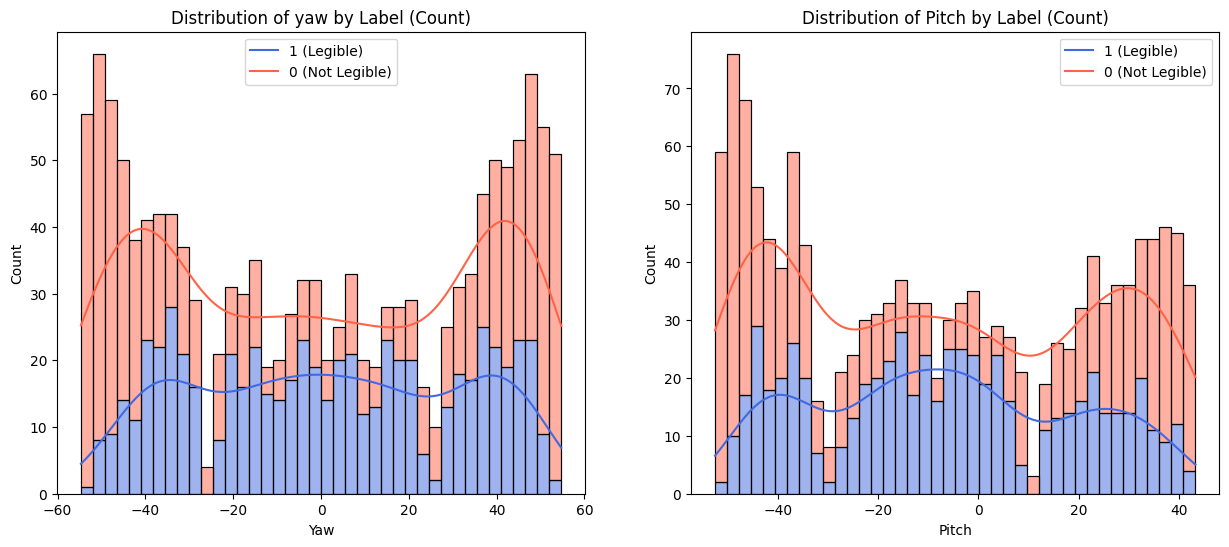

In [64]:
#Distribution of yaw and pitch by Label

fig, axes = plt.subplots(1,2, figsize=(15,6))
sns.histplot(data=df, x='yaw', hue='label', bins=40, kde=True, multiple='stack', ax=axes[0], palette={0: "tomato", 1: "royalblue"})
axes[0].set_title('Distribution of yaw by Label (Count)')
axes[0].set_xlabel('Yaw')
axes[0].set_ylabel('Count')
axes[0].legend(['1 (Legible)', '0 (Not Legible)'])

sns.histplot(data=df, x='pitch', hue='label', bins=40, kde=True, multiple='stack', ax=axes[1], palette={0: "tomato", 1: "royalblue"})
axes[1].set_title('Distribution of Pitch by Label (Count)')
axes[1].set_xlabel('Pitch')
axes[1].set_ylabel('Count')
axes[1].legend(['1 (Legible)', '0 (Not Legible)'])
plt.show()